# Task 5: Capstone, redesign one chart for the human visual system

**CLO1:** how the brain processes visual information.

I'm using `diamonds.csv` (53,940 rows). The one question a reader should be able to answer: **how much more does a diamond cost as it gets heavier?**

Plan: draw the worst honest version (every diamond, raw), audit it against everything from this week, rebuild it, audit the rebuild, test the rebuild on a person, and say what it costs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

d = pd.read_csv("diamonds.csv")
print(d.shape, "| missing values:", int(d.isna().sum().sum()))
print(d[["carat", "price"]].describe().round(2).T)
print(d.clarity.value_counts().to_dict())

(53940, 10) | missing values: 0
         count    mean      std    min    25%     50%      75%       max
carat  53940.0     0.8     0.47    0.2    0.4     0.7     1.04      5.01
price  53940.0  3932.8  3989.44  326.0  950.0  2401.0  5324.25  18823.00
{'SI1': 13065, 'VS2': 12258, 'SI2': 9194, 'VS1': 8171, 'VVS2': 5066, 'VVS1': 3655, 'IF': 1790, 'I1': 741}


## Step 1: the BAD EXAMPLE
All 53,940 diamonds plotted raw, price against carat, coloured by clarity (8 grades, 8 hues), full grid, box frame, legend. I plot the clarity grades in order from I1 up to IF, so the **last** one drawn is IF, which is the rarest grade after I1 (1,790 diamonds, about 3% of the data).

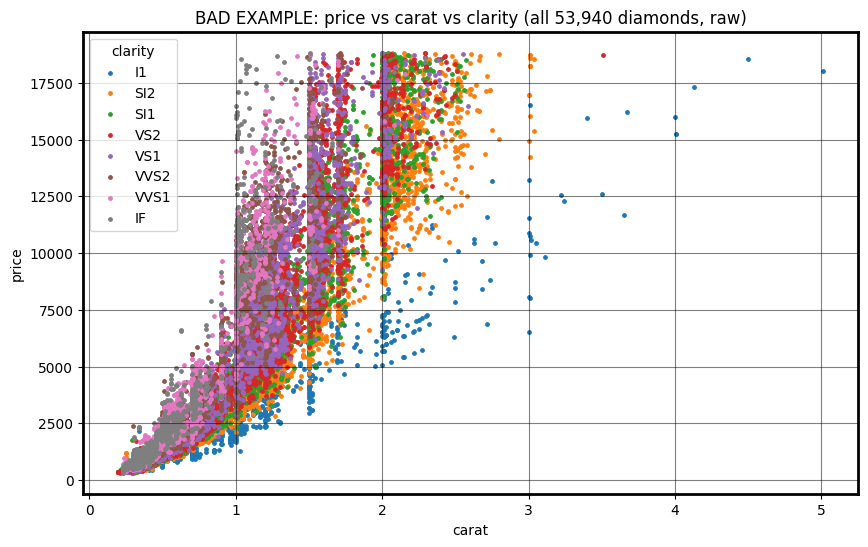

In [2]:
GRADES = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
HUES = plt.cm.tab10(np.arange(8))
fig, ax = plt.subplots(figsize=(10, 6))
for g_, c in zip(GRADES, HUES):
    s = d[d.clarity == g_]
    ax.scatter(s.carat, s.price, s=6, color=c, label=g_)
ax.grid(True, color="black", lw=0.8, alpha=0.5)
for sp in ax.spines.values(): sp.set_linewidth(2)
ax.legend(title="clarity", loc="upper left")
ax.set_xlabel("carat")
ax.set_ylabel("price")
ax.set_title("BAD EXAMPLE: price vs carat vs clarity (all 53,940 diamonds, raw)")
fig.savefig("t5_bad_example.png", dpi=300, bbox_inches="tight")
plt.show()

**The one question this chart should answer:** how much more does a diamond cost as it gets heavier?

## Step 2: perception audit of the BAD chart

| Row | Audit |
|---|---|
| **Preattentive** | Hue (8 colours) and position are in play. Position is doing useful work, because it's the carat and price. Hue is not: nothing in the question is about clarity, and eight hues is more than the eye can tell apart at a glance. |
| **Pop-out** | Whatever is drawn last. That's IF, a rare grade, so the eye is pulled to a small group of points the title doesn't mention. The thing that should pop out (the overall price-vs-carat trend) doesn't, because there's no single line or colour carrying it. |
| **Gestalt** | Similarity (same hue = same clarity) tries to create eight groups, and proximity merges 53,940 points into one dense blob. The layout groups the wrong things: eight colour groups, none of which answers the question. |
| **Cognitive load** | *Intrinsic:* the 53,940 points and the price/carat relationship. *Extraneous:* eight hues, the legend, heavy grid, thick frame, overplotting (points hiding each other), the title that just names the variables. *Germane:* axis labels and tick values (they turn position into numbers). |
| **Channels** | price: y-position (rank 1, right for a quantity). carat: x-position (rank 1, right). clarity: hue (an *ordered* variable on a categorical colour set, which the lowest-ranked channel, and the wrong kind). |
| **Working memory** | 8 colour-to-grade pairs to hold, plus the blob: well beyond 4 +/- 1. |

## Step 3: rebuild
**One message:** price climbs faster than weight. **Required items, and how I did them:**

- **One pop-out:** the median-price line, in the one strong colour (`#ee6677`). The two labelled markers sit on that line and are part of it, so they are the same element.
- **Context grey, message coloured:** a random sample of 3,000 diamonds in light grey shows how much prices spread around the line.
- **Named Gestalt principle: continuity.** The median line is a smooth path through carat, and the eye follows it as one trend. (Direct labels at the end of the line use proximity, instead of a legend.)
- **Most important variable on the highest-ranking channel:** price on vertical position, carat on horizontal position.
- **No info by colour alone:** the line is distinguished from the dots by *mark type* (a line vs points) and by a direct label, not only by colour.
- **`n` and exclusions on the figure.**

I dropped clarity, cut and colour from the chart entirely. They're not in the question.

median at ~0.5 ct: $1,607 (n=5031); at ~1.0 ct: $4,969 (n=5962); ratio = 3.09
rows above 3 ct excluded: 32 | rows in bins under 30: 51 | rows behind the line: 53857


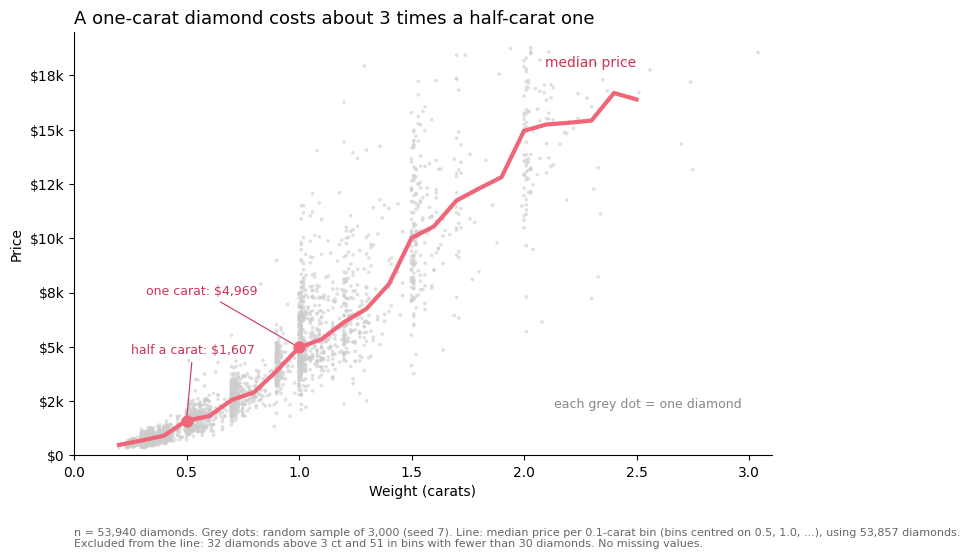

In [3]:
CAP = 3.0
BIN = 0.1
MIN_N = 30
use = d[d.carat <= CAP].copy()
use["bin"] = (np.floor((use.carat + BIN / 2) / BIN + 1e-9) * BIN).round(1)   # bins centred on 0.5, 1.0, ...
agg = use.groupby("bin").price.agg(["median", "size"])
keep = agg[agg["size"] >= MIN_N]
dropped_bins = agg[agg["size"] < MIN_N]
n_over_cap = int((d.carat > CAP).sum())
n_dropped_bin_rows = int(dropped_bins["size"].sum())
n_on_line = int(keep["size"].sum())
centres = keep.index

def window_median(c, w=0.05):
    s = d[(d.carat >= c - w) & (d.carat < c + w)]
    return s.price.median(), len(s)
half, n_half = window_median(0.5)
one, n_one = window_median(1.0)
ratio = one / half
print(f"median at ~0.5 ct: ${half:,.0f} (n={n_half}); at ~1.0 ct: ${one:,.0f} (n={n_one}); ratio = {ratio:.2f}")
print("rows above 3 ct excluded:", n_over_cap, "| rows in bins under 30:", n_dropped_bin_rows, "| rows behind the line:", n_on_line)

sample = d.sample(3000, random_state=7)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(sample.carat, sample.price, s=7, color="#cccccc", alpha=0.6, edgecolor="none", zorder=1)
ax.plot(centres, keep["median"], color="#ee6677", lw=3, zorder=3)
ax.scatter([0.5, 1.0], [half, one], s=60, color="#ee6677", zorder=4)
ax.annotate(f"half a carat: ${half:,.0f}", (0.5, half), xytext=(-40, 48), textcoords="offset points",
            fontsize=9, color="#cc3355", arrowprops=dict(arrowstyle="-", color="#cc3355", lw=0.8))
ax.annotate(f"one carat: ${one:,.0f}", (1.0, one), xytext=(-110, 38), textcoords="offset points",
            fontsize=9, color="#cc3355", arrowprops=dict(arrowstyle="-", color="#cc3355", lw=0.8))
ax.text(centres[-1], keep["median"].iloc[-1] + 1500, "median price", color="#cc3355", fontsize=10, ha="right")
ax.text(2.55, 2200, "each grey dot = one diamond", color="#888888", fontsize=9, ha="center")
ax.set_xlim(0, 3.1)
ax.set_ylim(0, 19500)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:.0f}k" if v else "$0"))
ax.set_xlabel("Weight (carats)")
ax.set_ylabel("Price")
ax.set_title(f"A one-carat diamond costs about {ratio:.0f} times a half-carat one", loc="left", fontsize=13)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.text(0, -0.17,
        f"n = {len(d):,} diamonds. Grey dots: random sample of 3,000 (seed 7). Line: median price per 0.1-carat bin (bins centred on 0.5, 1.0, ...), using {n_on_line:,} diamonds.\n"
        f"Excluded from the line: {n_over_cap} diamonds above 3 ct and {n_dropped_bin_rows} in bins with fewer than {MIN_N} diamonds. No missing values.",
        transform=ax.transAxes, fontsize=8, color="#666666", va="top")
fig.savefig("perception_redesign.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 4: the audit again, before and after

| Row | BAD EXAMPLE | Redesign |
|---|---|---|
| **Preattentive** | hue (8 colours) not doing useful work; position fine | one hue (the strong red) separates the message from the context; position carries both variables |
| **Pop-out** | the rare IF grade, drawn last, which is not what the question is about | the median line, which is what the title talks about; nothing else is coloured |
| **Gestalt** | similarity makes 8 irrelevant groups; proximity merges the points into a blob | continuity: the eye follows the line as one trend; proximity for the direct labels |
| **Cognitive load** | extraneous: 8 hues, legend, heavy grid, frame, overplotting, title that names the axes | intrinsic: the price-weight relationship. germane: axes, the two labelled points, the grey spread as context. extraneous: nothing I could find (no legend, no grid, no frame) |
| **Channels** | price and carat on position (good); clarity on hue (wrong) | price and carat on position; the only colour use is "this is the message", a nominal job hue is good at |
| **Working memory** | 8 colour-to-grade pairs plus a blob: well over 4 +/- 1 | 3 chunks: the grey cloud, the red line, the two labelled points |

## Step 5: test it on a person
I showed `perception_redesign.png`, and not the original, to someone who hadn't seen the data, and asked: **"in one sentence, what does this show?"**

Type their sentence into `reader_sentence.txt` (one line, exactly what they said). The next cell prints it.

In [4]:
if os.path.exists("reader_sentence.txt"):
    print("Reader said (verbatim):")
    print(open("reader_sentence.txt").read().strip())
else:
    print("reader_sentence.txt doesn't exist yet. Show the redesign to someone, write their sentence in that file, and re-run.")

reader_sentence.txt doesn't exist yet. Show the redesign to someone, write their sentence in that file, and re-run.


**Who was my reader:** _(first name, whether they know anything about diamonds)_

**Their sentence, verbatim:** _("...")_

**Does it match my title?** _(My title says a one-carat diamond costs about three times a half-carat one. If they said something else, which part of the design misled them? For example, the grey cloud pulling attention to the spread, the "median" word not meaning anything to them, or the axis in $k. And what I'd change next.)_

## Step 6: export
`perception_redesign.png` is saved above at `dpi=300` with `bbox_inches="tight"`. Check:

In [5]:
from PIL import Image
im = Image.open("perception_redesign.png")
print("size (px):", im.size, "| dpi stored in file:", im.info.get("dpi"))

size (px): (2910, 1683) | dpi stored in file: (299.9994, 299.9994)


## Self-audit
- [x] Every chart built with `fig, ax` (no `plt.plot` / `plt.bar`)
- [x] Exactly one pop-out element (the median line), and it carries the title's message
- [x] The Gestalt principle used is named: **continuity**
- [x] Most important variable on the highest-ranking available channel (price on position)
- [x] Every element classified as intrinsic / extraneous / germane (audit tables)
- [x] Reader holds about 3 chunks
- [x] No information carried by colour alone (line vs dots, plus direct labels)
- [x] Context greyed, message coloured
- [x] `n` and exclusions declared on the figure
- [x] Title states a finding
- [ ] A real reader's one-sentence reading is recorded verbatim *(needs a real person)*

## The question: what does my redesign make harder to see?
Several things, and I chose to lose them.

**Why prices differ at the same weight.** At one carat the dots run from well under the line to far above it, because clarity, cut and colour all move the price. I greyed that spread and dropped the variables that explain it, so the chart shows that prices scatter around the median but not why. A reader who cares which diamond is a bargain can't use this chart.

**What happens at round weights.** Diamonds pile up at 0.5, 1.0 and 1.5 carats because buyers and sellers favour round numbers, and prices jump just past those points. A 0.1-carat bin smooths that out, and the continuous line implies a steady climb that isn't quite there.

**The biggest stones.** The 32 diamonds above 3 carats are excluded, and bins under 30 diamonds are dropped, so the line stops where the data gets thin. That's honest, but it means the chart says nothing about the rarest, most expensive stones.